# Bank Marketing Classification

## Machine Learning Capstone Project

### Classification Track - Review 1

This notebook implements and evaluates machine learning classification algorithms using the Bank Marketing dataset.

The objective is to predict whether the client will subscribe to a term deposit on demographic, financial, and previous marketing campaign information.

This notebook covers: 

1. Dataset Loading and Audit
2. Exploratory Data Analysis
3. Data Cleaning
4. Preprocessing and Feature Engineering
5. Classification Model Implementation 
6. Model Evaluation and Comparison

# 1. Importing Required Libraries

In [22]:
# Data Manipulation
import pandas as pd
import numpy as np
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Display Settings
pd.set_option('display.max_columns', None)
# Reproductibility
RANDOM_STATE = 42

# 2. Dataset Loading

The `bank-full.csv` dataset is used for the final analysis and model development in this project.

This dataset contains the complete set of customer records from the Bank Marketing dataset and will be used to perform exploratory data analysis, preprocessing, feature engineering, and machine learning classification.

The objective is to build and evaluate classification models that predict whether a customer will subscribe to a bank term deposit.

In [23]:
# Load the dataset
file_path = '../data/classification/bank-full.csv'
df = pd.read_csv(file_path, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# 3.Dataset Audit

This section examines the structure and quality of the dataset, including its dimensions, data types, missing values, and target class distribution.

In [24]:
# Dataset dimensions
print("Dataset shape:", df.shape)
# Column data types
print("\n Data types:")
display(df.dtypes)
# Missing values
print("\n Missing values:")
display(df.isnull().sum())
# Target class distribution
print("\n Target class distribution:")
display(df['y'].value_counts())
print("\n Target class distribution (percentage):")
display(df['y'].value_counts(normalize=True) * 100)

Dataset shape: (45211, 17)

 Data types:


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


 Missing values:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


 Target class distribution:


y
no     39922
yes     5289
Name: count, dtype: int64


 Target class distribution (percentage):


y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

### Dataset Audit Insights

- The dataset contains **45,211 records**, consisting of **16 input features and one target variable (`y`)**.

- The dataset contains both numerical and categorical features, meaning categorical variables will require encoding before machine learning models can be trained.

- No missing values were identified in any column; therefore, missing-value imputation is not required.

- The target variable is significantly imbalanced, with approximately **88.30%** of customers belonging to the `no` class and **11.70%** belonging to the `yes` class.

- Because of this class imbalance, accuracy alone may not provide a complete evaluation of model performance. Additional evaluation metrics such as precision, recall, and F1 score will therefore also be considered.

# 4. Exploratory Data Analysis (EDA)

This section explores the distributions and relationships within the dataset using visualizations. The analysis focuses on the target variable, individual features distributions, correlations between numerical variables, and relationships between selected between selected features and the target variable.

## 4.1 Target Variable Distribution

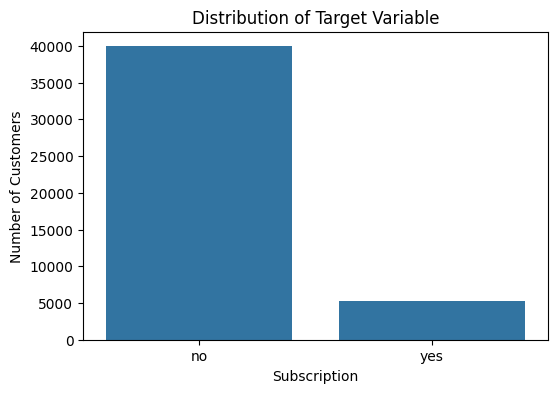

In [25]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data = df, x='y')
plt.title('Distribution of Target Variable')
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.show()

### Observation

The target variable is highly imbalanced. The majority of customers did not subscribe to a term deposit, while only a relatively small proportion subscribed.

This visualization confirms the class imbalance identified during the dataset audit and reinforces that model performance should not be evaluated using accuracy alone. Additional metrics, such as precision, recall, and F1 score, will also be considered.

## 4.2 Numerical Feature Distributions

In [26]:
# Identify numerical columns
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Remove the target variable if present
numerical_features = [col for col in numerical_features if col != 'y']
numerical_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

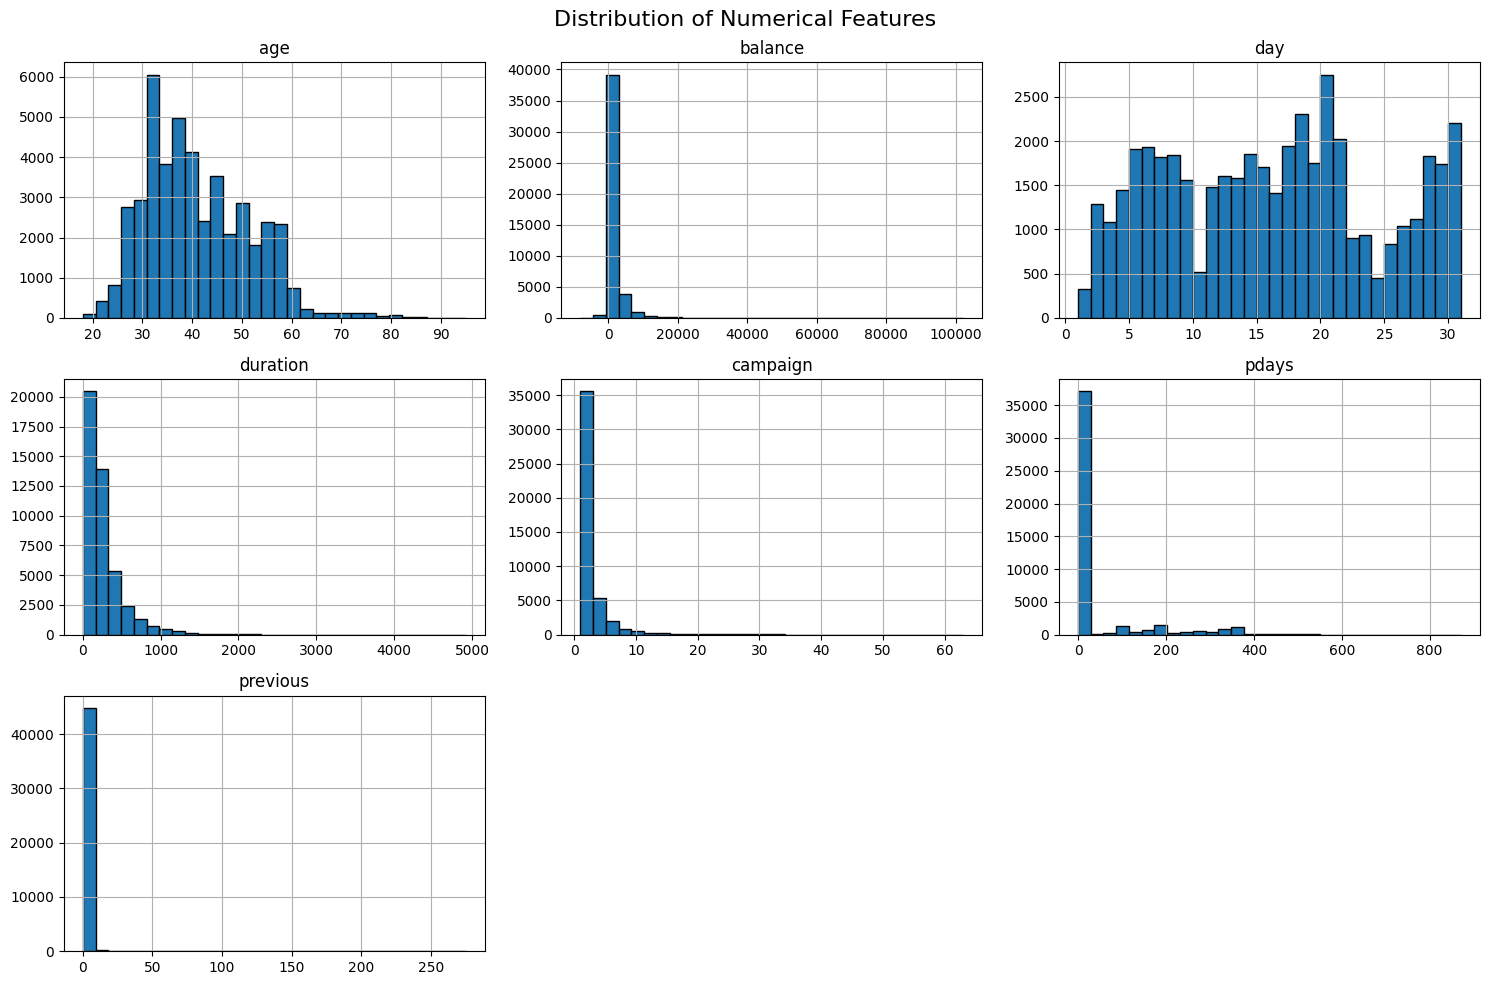

In [27]:
# Distribution plots for numerical features
df[numerical_features].hist(
figsize = (15,10),
bins = 30,
edgecolor = "black"
)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observations

- **Age:** Most customers are concentrated between approximately 30 and 50 years old, with fewer observations at the extreme ends of the age range.

- **Balance:** The balance feature is highly right-skewed. Most customers have relatively low account balances, while a small number have exceptionally high balances.

- **Day:** Customer contacts are distributed across the days of the month, although the distribution is not uniform.

- **Duration:** Call duration is strongly right-skewed. Most calls are relatively short, while a small number of calls have considerably longer durations.

- **Campaign:** Most customers were contacted only a small number of times during the campaign, with the frequency decreasing as the number of contacts increases.

- **Pdays:** A large proportion of observations have a value of `-1`, indicating that these customers were not previously contacted before the current campaign.

- **Previous:** The feature is heavily concentrated around zero, indicating that most customers had little or no contact during previous marketing campaigns.

## 4.3 Categorical Feature Distributions

In [28]:
# Identify categorical features
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
# Remove the target variable
categorical_features = [col for col in categorical_features if col != "y"]
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

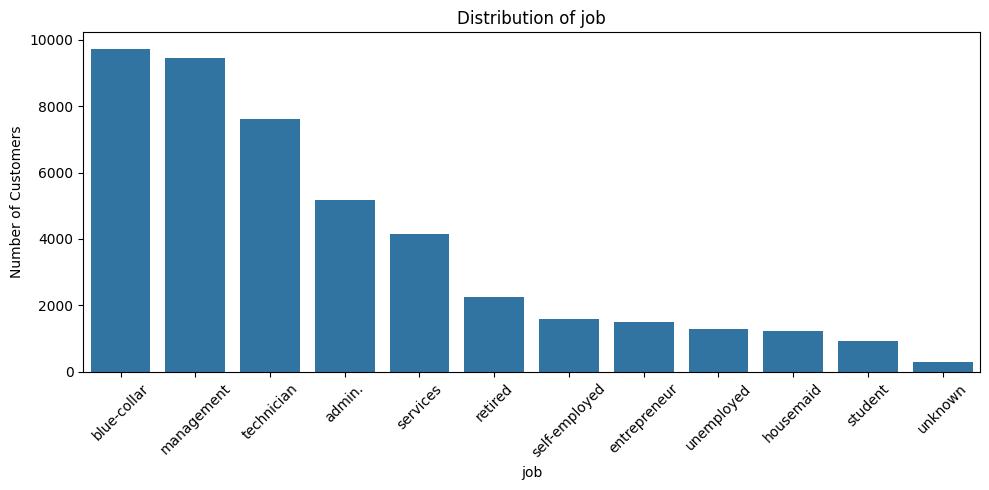

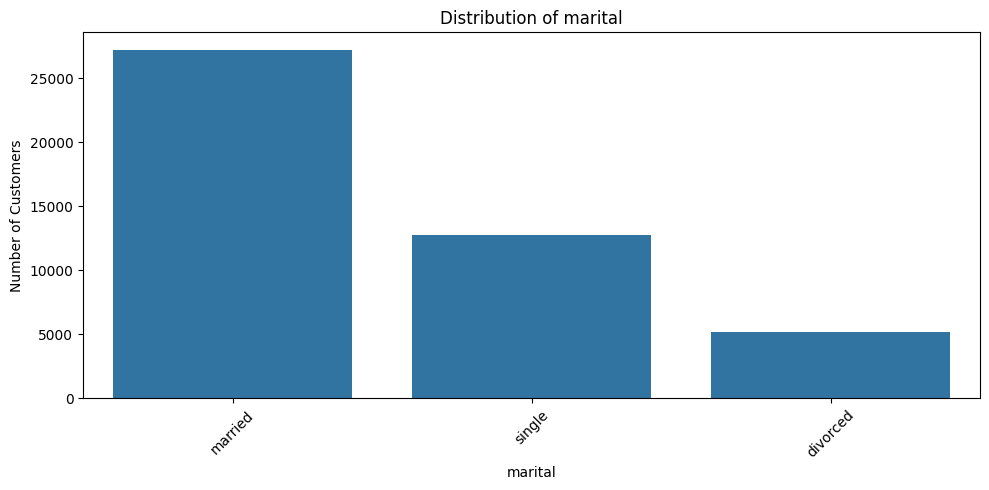

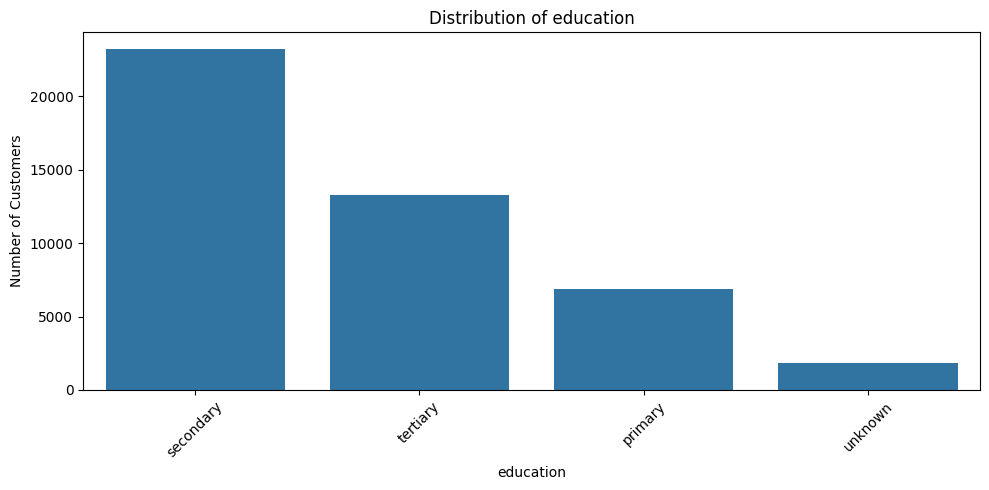

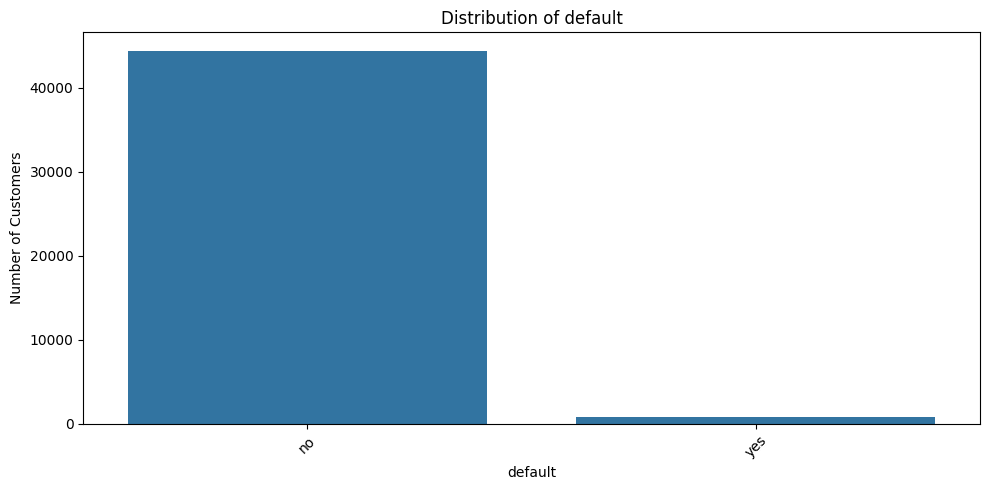

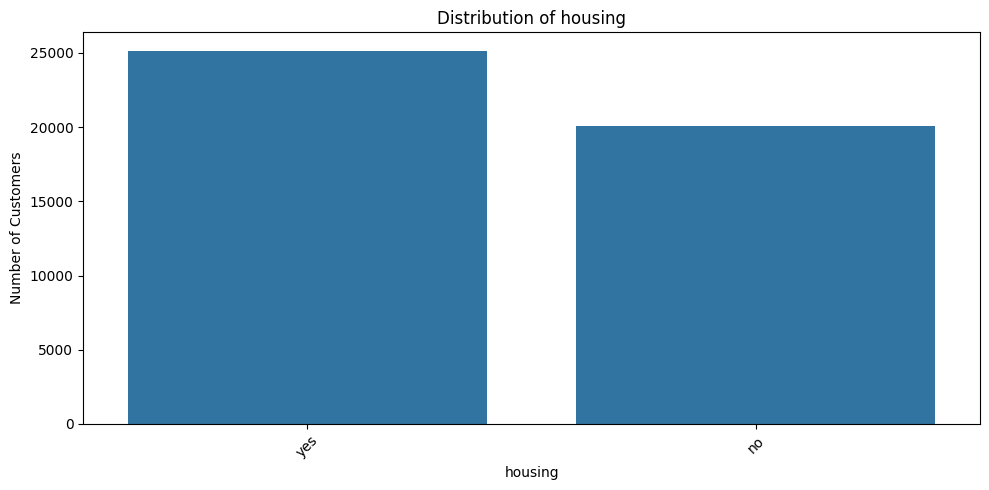

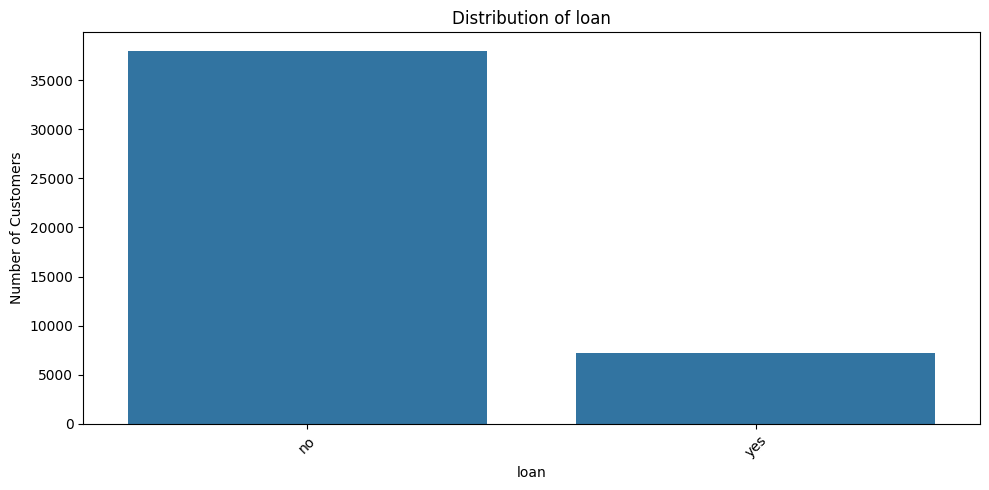

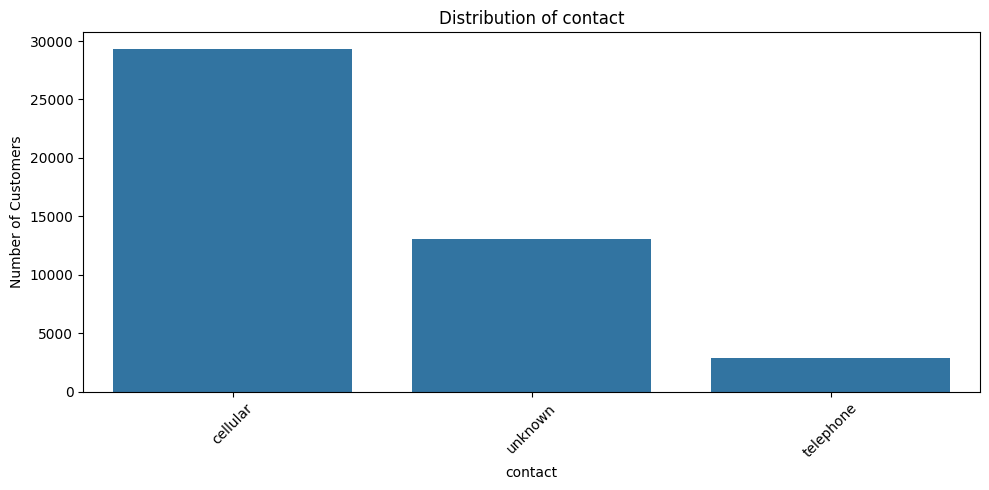

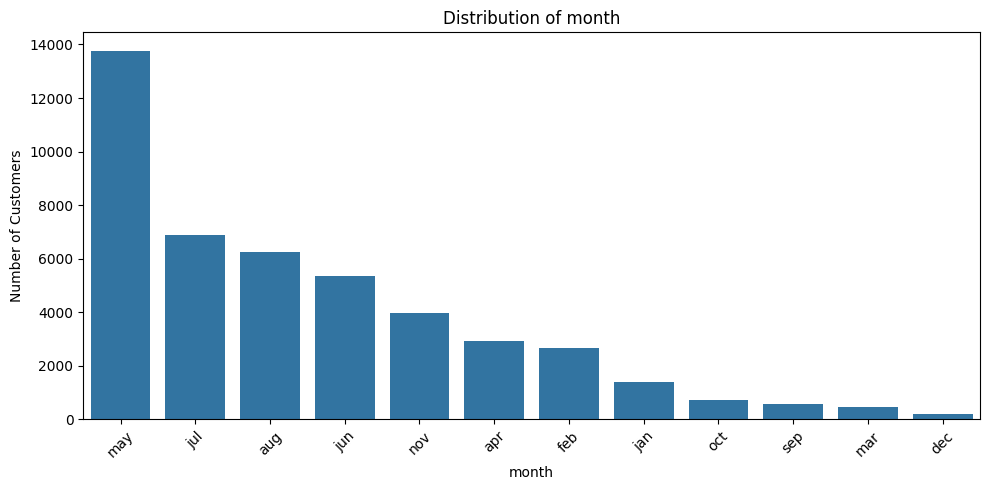

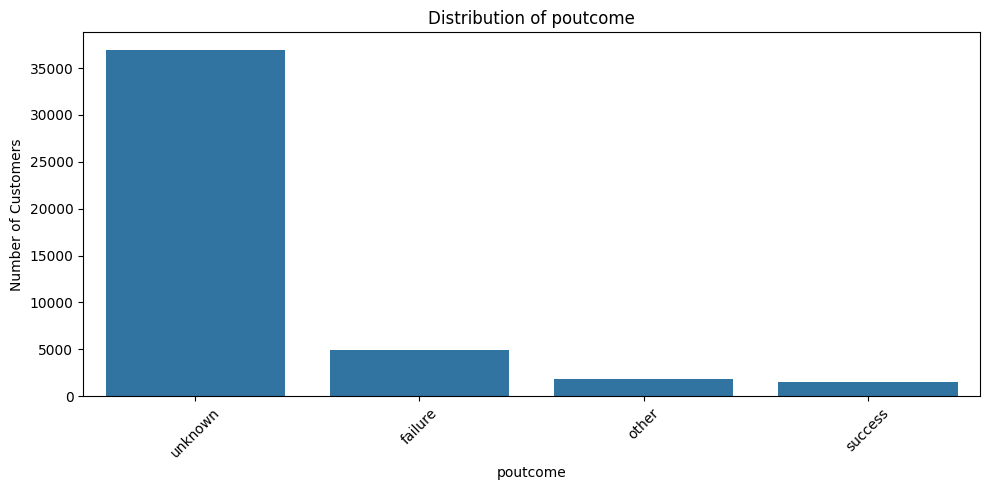

In [29]:
# Distribution plots for categorical features
for column in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Key Observations from Feature Distributions

- **Several numerical features**, including `balance`, `duration`, `campaign`, and `previous`, show right-skewed distributions. Most observations are concentrated at lower values, while a relatively small number of customers have exceptionally high values.

- **The `pdays` feature** contains a large concentration of `-1` values, indicating that many customers were not contacted before the current campaign.

- **Age:** Most customers fall within the middle-age range, particularly between approximately 30 and 50 years, while fewer observations occur at the extreme ends of the age distribution.

- **The categorical variables show varying levels of imbalance.** For example, the `default` feature is heavily dominated by customers who have not defaulted on credit.

- **Campaign activity is concentrated in specific months**, with May containing the highest number of customer contacts.

- **Contact methods are also unevenly distributed**, with cellular contact being the most commonly used method.

- **The `poutcome` feature is dominated by the `unknown` category**, indicating that the outcome of previous marketing campaigns is unavailable for a large proportion of customers.

- Overall, the dataset contains a mixture of numerical and categorical variables with different distributions and scales, highlighting the need for appropriate preprocessing before training machine learning models.

## Correlation Analysis

A correlation heatmap is used to examine the relationships between numerical features in the dataset.

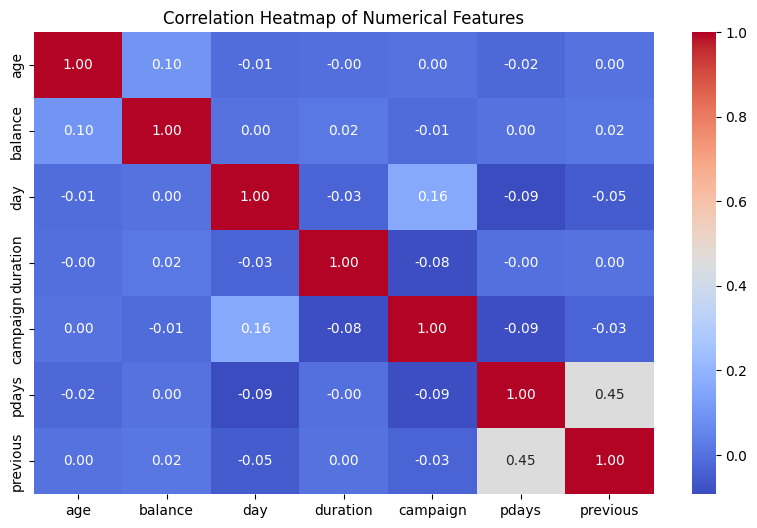

In [30]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_features].corr()
# Create the correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Insight

The correlation analysis shows that most numerical features have weak linear relationships with one another. The strongest positive correlation is between `pdays` and `previous` (0.45), indicating a moderate relationship between the number of days since a previous contact and the number of previous contacts.

Most other feature pairs have correlation values close to zero, suggesting that there are no strong linear relationships among the numerical features.

## Feature-Target Relationships

In [31]:
# Convert the target variable to numerical values for visualization
df['y_numeric'] = df['y'].map({'no': 0, 'yes': 1})
df[['y', 'y_numeric']].head()

,y,y_numeric
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


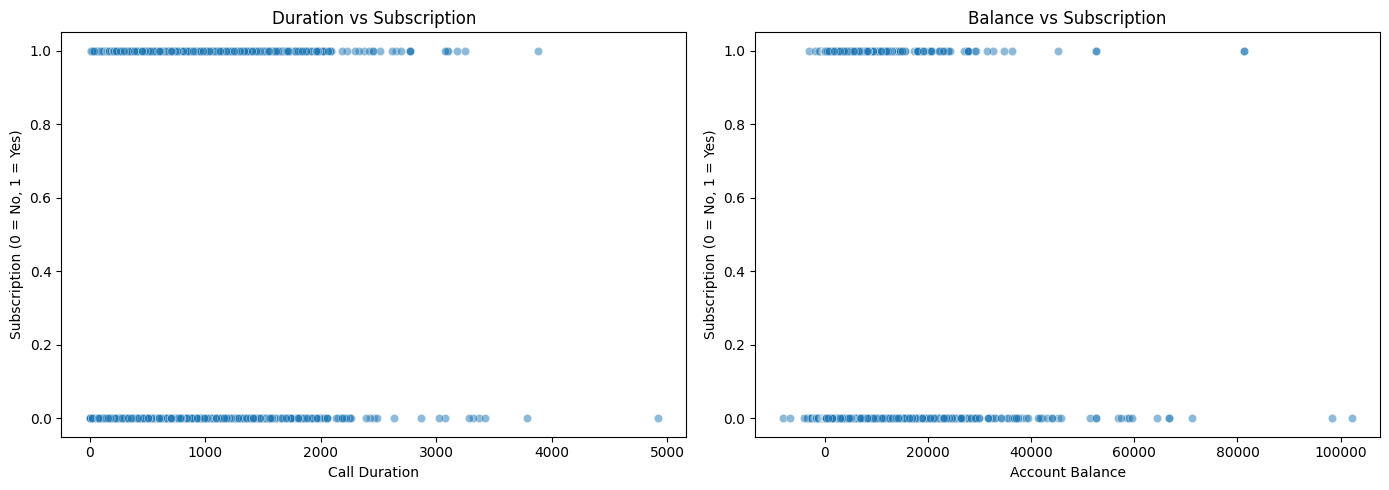

In [32]:
# Create scatter plots showing feature-target relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Duration vs Target
sns.scatterplot(
    data=df,
    x='duration',
    y='y_numeric',
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title('Duration vs Subscription')
axes[0].set_xlabel('Call Duration')
axes[0].set_ylabel('Subscription (0 = No, 1 = Yes)')
# Balance vs Target
sns.scatterplot(
    data=df,
    x='balance',
    y='y_numeric',
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title('Balance vs Subscription')
axes[1].set_xlabel('Account Balance')
axes[1].set_ylabel('Subscription (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()

### Insight

The scatter plots suggest that call duration has a stronger relationship with subscription outcome than account balance. Customers who subscribed generally appear more frequently among observations with longer call durations, indicating that `duration` may be a useful feature for predicting whether a customer will subscribe.

In contrast, account balance shows substantial overlap between customers who subscribed and those who did not, suggesting that `balance` alone may not effectively distinguish between the two classes. The presence of extreme balance values is also visible and should be considered during data preprocessing.

In [33]:
# Remove the temporary visualization column
df.drop(columns=['y_numeric'], inplace=True)

# 3. Data Cleaning

## Checking for Duplicate Records

In [34]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Insight

No duplicate records were found in the dataset. Therefore, no duplicate removal was necessary.

## Outlier Detection

Boxplots are used to identify potential outliers in the numerical features of the dataset.

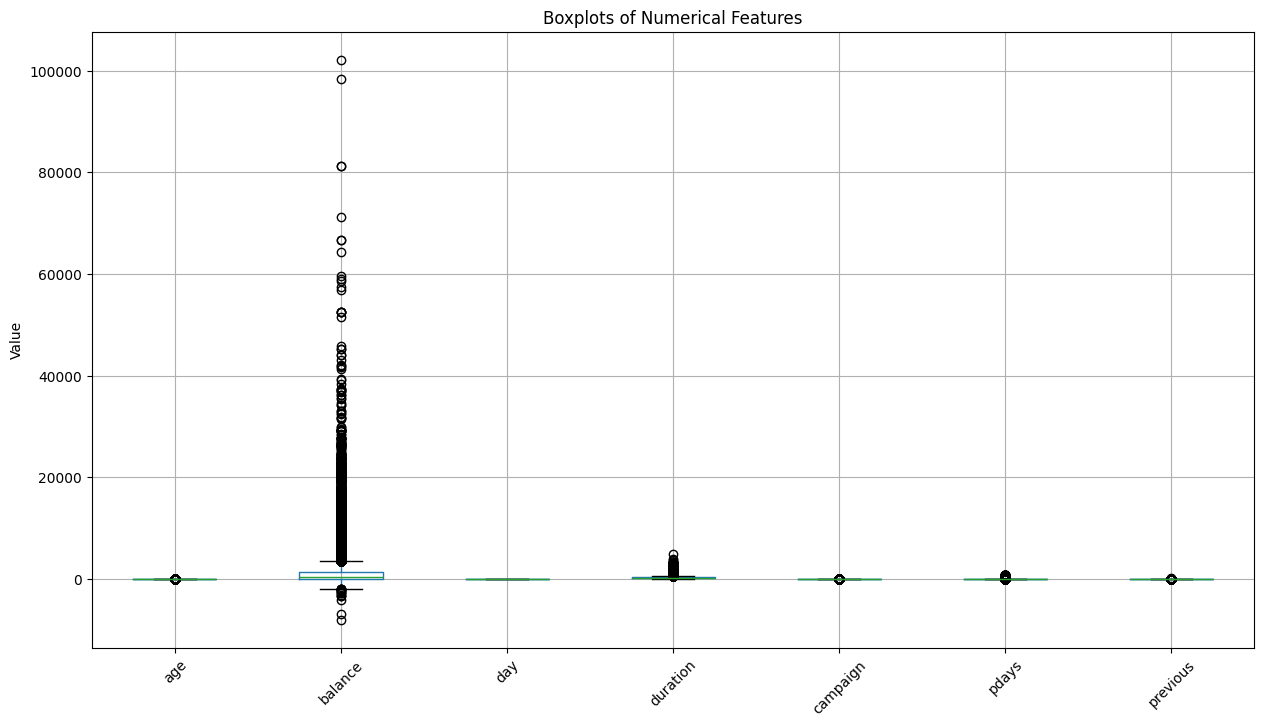

In [35]:
# Visualize potential outliers using boxplots
plt.figure(figsize=(15, 8))
df[numerical_features].boxplot()
plt.title('Boxplots of Numerical Features')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

In [36]:
# Count potential outliers using the IQR method
outlier_counts = {}
for column in numerical_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    outlier_counts[column] = len(outliers)
# Display the number of potential outliers
outlier_counts

{'age': 487,
 'balance': 4729,
 'day': 0,
 'duration': 3235,
 'campaign': 3064,
 'pdays': 8257,
 'previous': 8257}

### Outlier Analysis and Treatment

The IQR method identified potential outliers in several numerical features, particularly `balance`, `duration`, `campaign`, `pdays`, and `previous`. A substantial number of potential outliers were identified in `pdays` and `previous`, reflecting the highly skewed distributions of these features.

These observations were not automatically removed because extreme values may represent legitimate customer characteristics and campaign outcomes rather than data-entry errors. For example, a high account balance, a long call duration, or a large number of previous contacts can represent valid observations.

Therefore, the potential outliers will be retained. Appropriate preprocessing and scaling techniques will be applied during the model preparation stage where necessary to reduce the influence of differences in feature scales.

In [37]:
# Calculate the percentage of potential outliers
outlier_percentage = {
    column: round((count / len(df)) * 100, 2)
    for column, count in outlier_counts.items()
}
outlier_percentage

{'age': 1.08,
 'balance': 10.46,
 'day': 0.0,
 'duration': 7.16,
 'campaign': 6.78,
 'pdays': 18.26,
 'previous': 18.26}

### Final Data Cleaning Summary

The dataset contains no missing values and no duplicate records. Potential outliers were identified using the IQR method in several numerical features.

The highest proportions of potential outliers were found in `pdays` and `previous` (18.26%), followed by `balance` (10.46%). These observations were retained because they may represent legitimate customer and campaign characteristics rather than data-entry errors. Removing all of these observations could result in significant information loss.

Therefore, no rows were removed during the data cleaning stage. Appropriate encoding and scaling techniques will be applied during preprocessing.

# 4. Preprocessing and Feature Engineering

## Feature and Target Separation

The dataset is separated into input features (`X`) and the target variable (`y`) before performing the train-test split.

In [38]:
# Separate features and target variable
X = df.drop(columns=['y'])
y = df['y']
print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (45211, 16)
Target variable shape: (45211,)


In [39]:
print(X.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


## Train-Test Split

The dataset is divided into training and testing sets using a stratified split to preserve the original class distribution in both subsets.

In [40]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
# Display the shapes of the datasets
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (36168, 16)
Testing set shape: (9043, 16)

Training target distribution:
y
no     88.301814
yes    11.698186
Name: proportion, dtype: float64

Testing target distribution:
y
no     88.300343
yes    11.699657
Name: proportion, dtype: float64


### Split Verification

The stratified train-test split successfully preserved the original target class distribution in both the training and testing sets. This is particularly important because the target variable is imbalanced.

## Feature Identification

The input features are separated into numerical and categorical groups so that appropriate preprocessing techniques can be applied to each type.

In [41]:
# Identify categorical and numerical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()
print("Numerical features:")
print(numerical_features)
print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## Encoding and Scaling

Numerical features are standardized using `StandardScaler`, while categorical features are transformed using one-hot encoding. The preprocessing transformations are fitted only on the training data to prevent data leakage.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Define preprocessing for numerical features: standard scaling
numerical_transformer = StandardScaler()
# Define preprocessing for categorical features: one-hot encoding
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)
# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [43]:
# Fit the preprocessor on the training data only
X_train_preprocessed = preprocessor.fit_transform(X_train)
# Transform the test data using the fitted preprocessor
X_test_preprocessed = preprocessor.transform(X_test)
print("Processed training set shape:", X_train_preprocessed.shape)
print("Processed test set shape:", X_test_preprocessed.shape)

Processed training set shape: (36168, 51)
Processed test set shape: (9043, 51)


### Preprocessing Results

The preprocessing pipeline was successfully applied to the dataset. The original 16 input features were transformed into 51 features after numerical scaling and one-hot encoding of categorical variables.

The preprocessing transformations were fitted exclusively on the training data and then applied to the testing data, preventing data leakage.

## Feature Engineering

A new feature named `previously_contacted` is created using the `pdays` variable. In this dataset, a value of `-1` in `pdays` indicates that the customer was not contacted during a previous marketing campaign.

The engineered feature explicitly distinguishes customers who had previous campaign contact from those who did not. This may improve model performance by providing a clearer representation of previous customer interaction history.

In [44]:
# Create a binary feature indicating whether the customer was contacted during the previous campaign
df['previously_contacted'] = (df["pdays"] != -1).astype(int)
# Display the distribution of the new feature
df['previously_contacted'].value_counts()

previously_contacted
0    36954
1     8257
Name: count, dtype: int64

In [45]:
print("Previously contacted feature distribution:")
print(df['previously_contacted'].value_counts())
print("\nPreviously contacted feature distribution (percentage):")
print(df['previously_contacted'].value_counts(normalize=True) * 100)

Previously contacted feature distribution:
previously_contacted
0    36954
1     8257
Name: count, dtype: int64

Previously contacted feature distribution (percentage):
previously_contacted
0    81.736745
1    18.263255
Name: proportion, dtype: float64


In [46]:
df[["pdays", "previously_contacted"]].head(10)

,pdays,previously_contacted
0,-1,0
1,-1,0
2,-1,0
3,-1,0
4,-1,0
5,-1,0
6,-1,0
7,-1,0
8,-1,0
9,-1,0


In [47]:
# Separate features and target variable
X = df.drop(columns=['y', 'y_numeric'], errors='ignore')
y = df['y']
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (45211, 17)
Target vector shape: (45211,)


# 5. Classification Model Implementation

This section implements and evaluates multiple machine learning classification models for predicting whether a customer will subscribe to the bank's term deposit product.

## Model 1: Logistic Regression

Logistic Regression is used as a baseline classification model. It is suitable for binary classification problems and provides a useful benchmark for comparing the performance of more complex models.

In [48]:
from sklearn.linear_model import LogisticRegression
# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)
# Train the model 
logistic_model.fit(X_train_preprocessed, y_train)
# Make predictions
y_pred_logistic = logistic_model.predict(X_test_preprocessed)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# Calculate evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    pos_label='yes',
    zero_division=0
)
recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    pos_label='yes',
    zero_division=0
)
f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    pos_label='yes',
    zero_division=0
)
# Print the evaluation metrics
print("Logistic Regression Model Evaluation Metrics:")
print("-" * 40)
print(f"Accuracy: {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall: {recall_logistic:.4f}")
print(f"F1 Score: {f1_logistic:.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    zero_division=0))

Logistic Regression Model Evaluation Metrics:
----------------------------------------
Accuracy: 0.9012
Precision: 0.6445
Recall: 0.3478
F1 Score: 0.4518

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7985
         yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



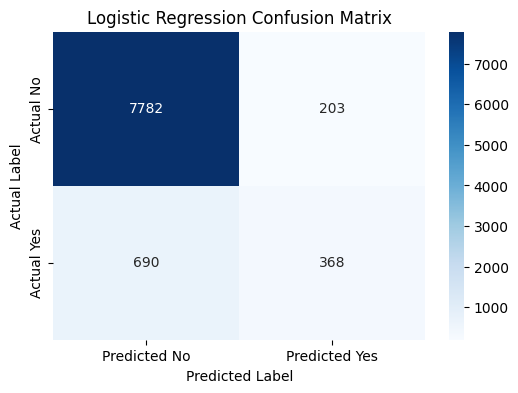

In [61]:
# Generate the confusion matrix
conf_matrix_logistic = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=['no', 'yes']
)
# Display the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_logistic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### Logistic Regression Results and Interpretation

The Logistic Regression model achieved an accuracy of **90.12%**. However, because the target variable is imbalanced, accuracy alone is not sufficient to fully evaluate model performance.

For the positive class (`yes`), the model achieved a precision of **64.45%**, recall of **34.78%**, and an F1-score of **45.18%**.

The confusion matrix shows that the model correctly identified **368 customers who subscribed** to the term deposit. However, it failed to identify **690 actual subscribers**, which were incorrectly classified as non-subscribers.

The model performed very well when identifying customers who did not subscribe, correctly classifying **7,782 non-subscribers**. Overall, Logistic Regression provides strong baseline accuracy and relatively good precision, but its recall for the minority subscription class remains limited. This means that a considerable number of potential subscribers are still missed by the model.

## Model 2: K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification. It predicts the class of a data point based on the classes of its nearest neighbours in the feature space.

Since KNN relies on distance-based calculations, feature scaling is important to ensure that features with larger numerical ranges do not disproportionately influence the model.

KNN will be evaluated and compared with the Logistic Regression baseline model using appropriate classification performance metrics.

In [51]:
from sklearn.neighbors import KNeighborsClassifier
# Create the K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)
# Train the model
knn_model.fit(X_train_preprocessed, y_train)
# Make predictions
y_pred_knn = knn_model.predict(X_test_preprocessed)
print("K-Nearest Neighbors model trained successfully.")

K-Nearest Neighbors model trained successfully.


In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# Calculate evaluation metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, pos_label='yes')
recall_knn = recall_score(y_test, y_pred_knn, pos_label='yes')
f1_knn = f1_score(y_test, y_pred_knn, pos_label='yes')
# Display evaluation metrics
print("K-Nearest Neighbors Model Evaluation Metrics:")
print("-" * 40)
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors Model Evaluation Metrics:
----------------------------------------
Accuracy: 0.8962
Precision: 0.5990
Recall: 0.3403
F1 Score: 0.4340

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7985
         yes       0.60      0.34      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.66      0.69      9043
weighted avg       0.88      0.90      0.88      9043



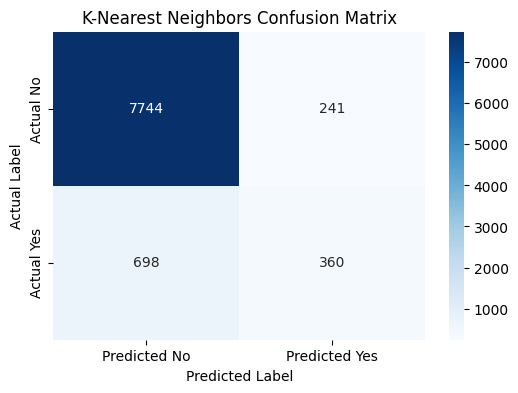

In [63]:
# Create the confusion matrix
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=['no', 'yes']
)
# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [54]:
# Define the values of K to test
k_values = range(1, 22, 2)
# Store the results
knn_results = []
for k in k_values:
    # Create and train the KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_preprocessed, y_train)
    # Make predictions
    y_pred = knn.predict(X_test_preprocessed)
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        pos_label='yes',
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        pos_label='yes',
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        pos_label='yes',
        zero_division=0
    )
    # Store the results
    knn_results.append({
        'K': k,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
# Convert results into a DataFrame
knn_results_df = pd.DataFrame(knn_results)
# Display the results
knn_results_df

,K,Accuracy,Precision,Recall,F1 Score
0,1,0.881234,0.491416,0.432892,0.460302
1,3,0.894725,0.579580,0.364839,0.447796
2,5,0.896163,0.599002,0.340265,0.433996
3,7,0.898596,0.625668,0.331758,0.433601
4,9,0.902134,0.659300,0.338374,0.447220
5,11,0.901692,0.663443,0.324197,0.435556
6,13,0.901360,0.670782,0.308129,0.422280
7,15,0.901250,0.676660,0.298677,0.414426
8,17,0.900365,0.670282,0.292060,0.406847
9,19,0.898596,0.657016,0.278828,0.391506


### Hyperparameter Tuning: Selecting the Optimal K

The performance of the K-Nearest Neighbors model was evaluated using multiple values of K.

The tested values were:

`K = 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, and 21`

Since the dataset contains an imbalanced target variable, accuracy alone was not used to select the optimal value of K. Recall and F1 score were also considered because identifying customers who are likely to subscribe is an important objective of the classification model.

Among the tested values, **K = 1 achieved the highest recall and F1 score**. Although some larger K values achieved slightly higher accuracy, they identified fewer actual subscribers.

Therefore, **K = 1 was selected as the optimal value for the K-Nearest Neighbors model** based on its overall ability to identify positive subscription cases.

### Final K-Nearest Neighbors Model

The K-Nearest Neighbors model will now be trained using the optimal value of **K = 1** identified during hyperparameter tuning.

In [55]:
# Create the final K-Nearest Neighbors model using the optimal K value
final_knn_model = KNeighborsClassifier(n_neighbors=1)
# Train the model
final_knn_model.fit(X_train_preprocessed,y_train)
# Make predictions
y_pred_knn_final = final_knn_model.predict(X_test_preprocessed)
print("Final K-Nearest Neighbors model trained successfully.")

Final K-Nearest Neighbors model trained successfully.


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# Evaluate the final tuned KNN model
accuracy_knn_final = accuracy_score(y_test,y_pred_knn_final)
precision_knn_final = precision_score(y_test,y_pred_knn_final,pos_label='yes')
recall_knn_final = recall_score(y_test,y_pred_knn_final,pos_label='yes')
f1_knn_final = f1_score(y_test,y_pred_knn_final,pos_label='yes')
print("Final K-Nearest Neighbors Model Evaluation Metrics:")
print("-" * 40)
print(f"Accuracy: {accuracy_knn_final:.4f}")
print(f"Precision: {precision_knn_final:.4f}")
print(f"Recall: {recall_knn_final:.4f}")
print(f"F1 Score: {f1_knn_final:.4f}")
print("\nClassification Report:")
print(
    classification_report(y_test,y_pred_knn_final)
)

Final K-Nearest Neighbors Model Evaluation Metrics:
----------------------------------------
Accuracy: 0.8812
Precision: 0.4914
Recall: 0.4329
F1 Score: 0.4603

Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.94      0.93      7985
         yes       0.49      0.43      0.46      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.69      0.70      9043
weighted avg       0.88      0.88      0.88      9043



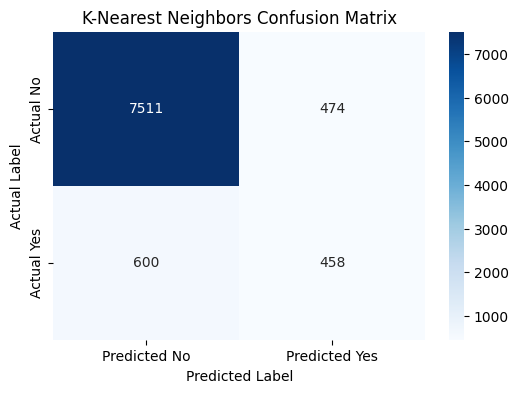

In [65]:
# Create the confusion matrix
cm_knn_final = confusion_matrix(
    y_test,
    y_pred_knn_final,
    labels=['no', 'yes']
)
# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_knn_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### K-Nearest Neighbors Results and Interpretation

The K-Nearest Neighbors model was initially evaluated using the default value of K = 5 and subsequently tuned by testing multiple values of K.

The hyperparameter tuning process identified **K = 1** as the preferred value based on its stronger recall and F1 score for the positive subscription class.

The tuned model achieved an accuracy of **88.12%**, a precision of **49.14%**, a recall of **43.29%**, and an F1 score of **46.03%**.

Although the tuned model achieved a lower overall accuracy compared to the initial K = 5 model, it demonstrated an improved ability to identify customers who actually subscribed to the term deposit.

The recall increased from approximately **34.03%** to **43.29%**, while the F1 score improved from approximately **43.40%** to **46.03%**.

This improvement came at the cost of lower precision and additional false positive predictions. However, considering the imbalanced nature of the dataset and the importance of identifying potential subscribers, the improved recall and F1 score make the tuned K = 1 model more suitable for this classification task.

Overall, hyperparameter tuning improved the K-Nearest Neighbors model's ability to identify positive subscription cases.

## Model 3: Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem.

It assumes that the numerical features follow a Gaussian (normal) distribution within each class and that the features are conditionally independent given the target class.

Gaussian Naive Bayes is computationally efficient and can serve as a useful comparison with the Logistic Regression and K-Nearest Neighbors models.

In [58]:
from sklearn.naive_bayes import GaussianNB
# Create the Gaussian Naive Bayes model
gaussian_nb_model = GaussianNB()
# Train the model
gaussian_nb_model.fit(X_train_preprocessed,y_train)
# Make predictions
y_pred_gaussian_nb = gaussian_nb_model.predict(X_test_preprocessed)
print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# Calculate evaluation metrics
accuracy_gaussian_nb = accuracy_score(y_test,y_pred_gaussian_nb)
precision_gaussian_nb = precision_score(y_test,y_pred_gaussian_nb,pos_label='yes')
recall_gaussian_nb = recall_score(y_test,y_pred_gaussian_nb,pos_label='yes')
f1_gaussian_nb = f1_score(
    y_test,y_pred_gaussian_nb,pos_label='yes')
# Display the results
print("Gaussian Naive Bayes Model Evaluation Metrics:")
print("-" * 40)
print(f"Accuracy: {accuracy_gaussian_nb:.4f}")
print(f"Precision: {precision_gaussian_nb:.4f}")
print(f"Recall: {recall_gaussian_nb:.4f}")
print(f"F1 Score: {f1_gaussian_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test,y_pred_gaussian_nb))

Gaussian Naive Bayes Model Evaluation Metrics:
----------------------------------------
Accuracy: 0.8548
Precision: 0.4059
Recall: 0.5198
F1 Score: 0.4559

Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.90      0.92      7985
         yes       0.41      0.52      0.46      1058

    accuracy                           0.85      9043
   macro avg       0.67      0.71      0.69      9043
weighted avg       0.87      0.85      0.86      9043



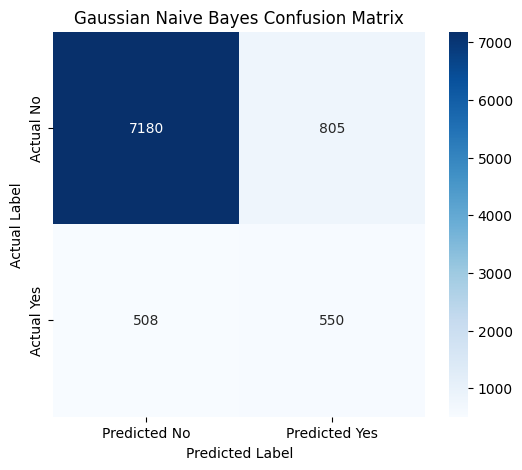

In [60]:
# Generate the confusion matrix
cm_gaussian_nb = confusion_matrix(
    y_test,
    y_pred_gaussian_nb,
    labels=['no', 'yes']
)
# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_gaussian_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)
plt.title('Gaussian Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### Model Evaluation

The performance of the Gaussian Naive Bayes model will be evaluated using several classification metrics.

The evaluation metrics include:

- **Accuracy:** Measures the overall proportion of correct predictions.
- **Precision:** Measures how many customers predicted to subscribe actually subscribed.
- **Recall:** Measures how many actual subscribers were correctly identified by the model.
- **F1 Score:** Provides a balance between precision and recall.

Since the dataset contains an imbalanced target variable, accuracy alone may not provide a complete picture of model performance. Therefore, precision, recall, and F1 score will also be considered when evaluating the model.

### Gaussian Naive Bayes Results and Interpretation

The Gaussian Naive Bayes model achieved an accuracy of **85.48%**, which is lower than both the Logistic Regression and K-Nearest Neighbors models.

However, accuracy alone does not provide a complete evaluation because the dataset contains significantly more customers who did not subscribe than customers who did.

The model achieved:

- **Precision:** 40.59%

- **Recall:** 51.98%

- **F1 Score:** 45.59%

The model achieved the highest recall among the models evaluated. It correctly identified **550 out of 1,058 actual subscribers**.

However, the precision was relatively low at **40.59%**, meaning that a considerable number of customers predicted to subscribe did not actually subscribe.

From the confusion matrix:

- **7,180 customers** were correctly predicted as not subscribing.

- **550 customers** were correctly predicted as subscribing.

- **805 customers** who did not subscribe were incorrectly predicted as subscribing.

- **508 actual subscribers** were incorrectly predicted as not subscribing.

The relatively high recall indicates that Gaussian Naive Bayes is more effective at identifying potential subscribers compared to the previous models. However, this comes at the cost of lower precision and overall accuracy.

This behaviour may be influenced by the assumptions made by the Gaussian Naive Bayes algorithm, particularly the assumption that the input features are conditionally independent.

Overall, the Gaussian Naive Bayes model provides a useful comparison because it demonstrates the trade-off between identifying more potential subscribers and making more false positive predictions.